In [2]:
from core import DataFrame
from io_module import read_csv_chunks
from processing import ChunkProcessor

reader = read_csv_chunks("../data/spotify_songs.csv", chunk_size=1000)
# 只收集前 5000 行
df = ChunkProcessor.collect_chunks(reader, max_rows=5000)
df

track_id             | track_name           | track_artist     | track_popularity | track_album_id       | track_album_name     | track_album_release_date | playlist_name | playlist_id          | playlist_genre | playlist_subgenre | danceability | energy | key | loudness | mode | speechiness | acousticness | instrumentalness | liveness | valence | tempo   | duration_ms
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
6f807x0ima9a1j3VP... | I Don't Care (wit... | Ed Sheeran       | 66               | 2oCs0DGTsRO98Gh5Z... | I Don't Care (wit... | 2019-06-14           | Pop Remix     | 37i9dQZF1DXcZDD7c... | pop            | dance pop         | 0.748        | 0.916  | 6  

正在載入資料...
成功載入 32833 筆資料。
正在進行分組聚合分析...


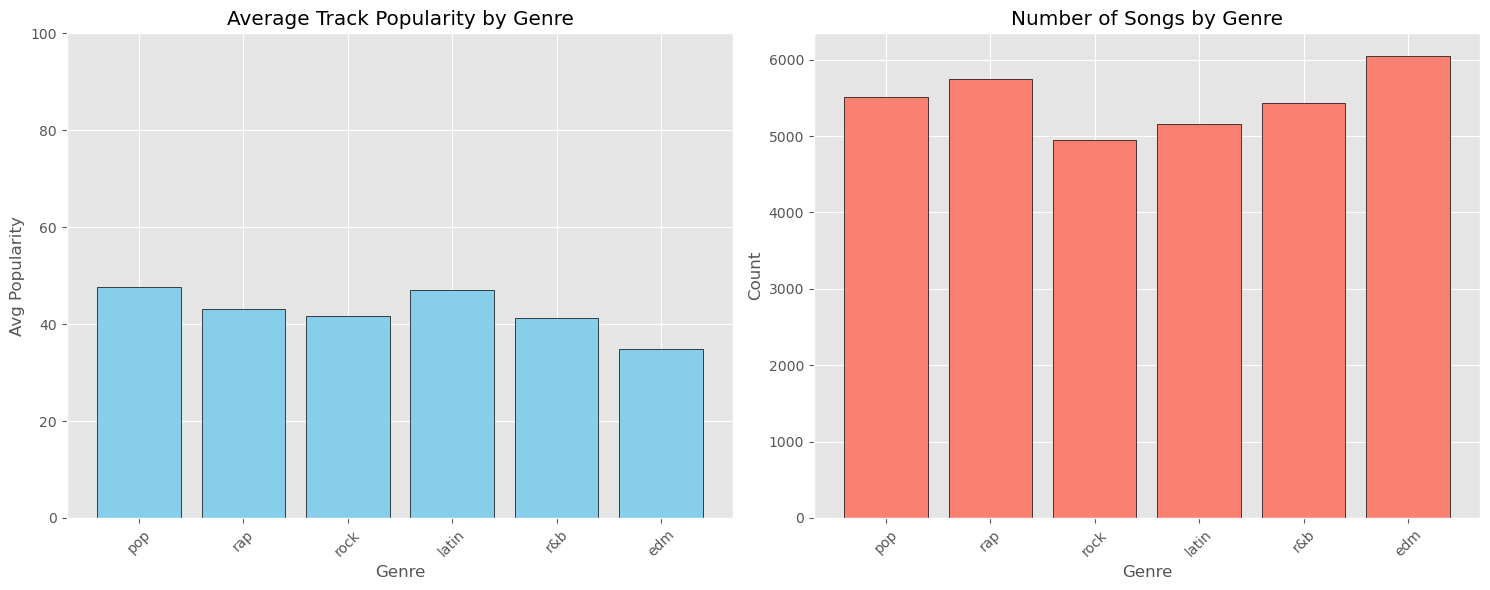

In [8]:
import matplotlib.pyplot as plt


# 1. 載入資料
print("正在載入資料...")
df = DataFrame.from_csv("../data/spotify_songs.csv")
print(f"成功載入 {df.row_count} 筆資料。")

# 2. 資料聚合
print("正在進行分組聚合分析...")
grouped_genre = df.groupby('playlist_genre')

genre_stats = grouped_genre.aggregate({
    'track_popularity': 'mean',
    'track_id': 'count'
})

# 3. 準備繪圖資料
genres = genre_stats['playlist_genre']
avg_popularity = genre_stats['track_popularity_mean']
song_counts = genre_stats['track_id_count']

# 4. 視覺化
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 左圖
ax1.bar(genres, avg_popularity, color='skyblue', edgecolor='black')
ax1.set_title('Average Track Popularity by Genre')
ax1.set_xlabel('Genre')
ax1.set_ylabel('Avg Popularity')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(0, 100)

# 右圖
ax2.bar(genres, song_counts, color='salmon', edgecolor='black')
ax2.set_title('Number of Songs by Genre')
ax2.set_xlabel('Genre')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()  # Jupyter Notebook 需要這行來顯示圖表

In [10]:
avg_popularity

[47.74487016524424,
 43.21545422902889,
 41.72833770955363,
 47.026576139670226,
 41.22353157797827,
 34.83352639417508]